# Warstwowa zależność efektów interwencji

Analiza wykorzystuje wszystkie zapisane warstwy wybrane do interwencji. Najpierw pokazuje ich położenie, następnie efekt według względnej głębokości, a na końcu według rangi KS.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src').is_dir()), Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from src.analysis.intervention_results import (
    load_all_intervention_runs, outcome_metrics, paired_branch_metrics,
)
from src.analysis.run_discovery import INTERVENTION_LABELS, apply_model_order

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'font.family': 'DejaVu Sans', 'axes.unicode_minus': False})
pd.set_option('display.max_columns', 60)

In [2]:
runs = load_all_intervention_runs()
accepted = apply_model_order(pd.concat([run['accepted'] for run in runs], ignore_index=True))
selected = apply_model_order(pd.concat([run['selected'] for run in runs], ignore_index=True))

## Położenie warstw wybranych przez KS

,model,feature,selection_rank,layer_number,layer_pct,ks_statistic
8,Qwen 0.5B,entropia odpowiedzi,1,24,100.000,0.366
9,Qwen 0.5B,entropia odpowiedzi,2,22,91.667,0.359
10,Qwen 0.5B,entropia odpowiedzi,3,23,95.833,0.336
11,Qwen 0.5B,entropia odpowiedzi,4,19,79.167,0.294
20,Qwen 3B,entropia odpowiedzi,1,32,88.889,0.475
21,Qwen 3B,entropia odpowiedzi,2,35,97.222,0.472
22,Qwen 3B,entropia odpowiedzi,3,36,100.000,0.471
23,Qwen 3B,entropia odpowiedzi,4,33,91.667,0.447
32,Qwen 7B,entropia odpowiedzi,1,28,100.000,0.421
33,Qwen 7B,entropia odpowiedzi,2,25,89.286,0.406


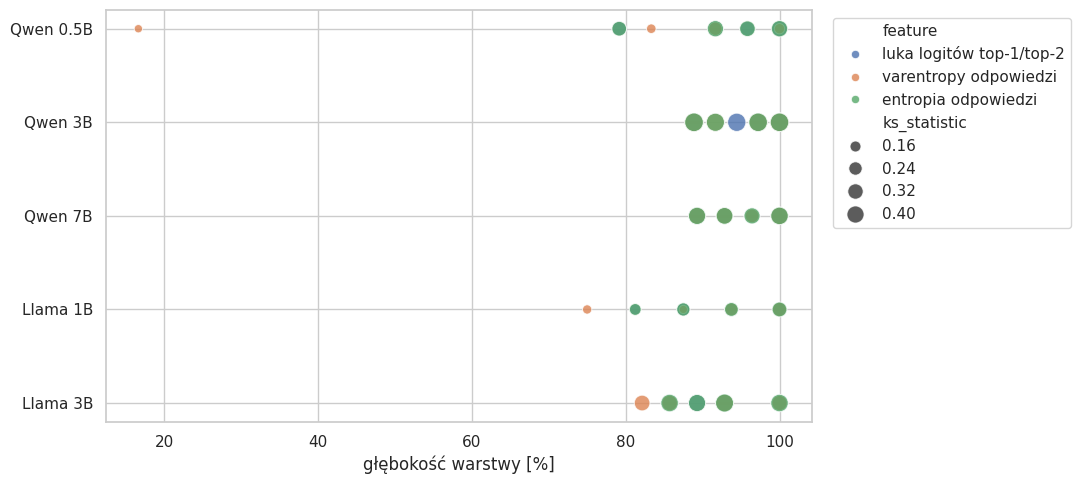

In [3]:
display(selected[[
    'model', 'feature', 'selection_rank', 'layer_number', 'layer_pct', 'ks_statistic'
]].sort_values(['feature', 'model', 'selection_rank']).round(3))

plt.figure(figsize=(11, 5))
sns.scatterplot(
    data=selected, x='layer_pct', y='model', hue='feature',
    size='ks_statistic', sizes=(35, 180), alpha=0.8,
)
plt.xlabel('głębokość warstwy [%]')
plt.ylabel('')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

## Efekt według względnej głębokości

,intervention_type,depth_bin,delta_accuracy,rescue_rate,harm_rate,mean_margin_change,wariant
0,ascent,0–20%,0.0000,0.0000,0.0000,0.0139,ascent
1,ascent,60–80%,0.0047,0.0188,0.0141,-0.0078,ascent
2,ascent,80–100%,-0.0120,0.0279,0.0399,0.2500,ascent
3,descent,0–20%,0.0000,0.0000,0.0000,-0.0139,descent
4,descent,60–80%,-0.0082,0.0175,0.0256,-0.0058,descent
5,descent,80–100%,-0.0900,0.0771,0.1671,-1.6230,descent
6,random_same_norm,0–20%,0.0000,0.0000,0.0000,0.0139,random
7,random_same_norm,60–80%,0.0037,0.0173,0.0136,-0.0010,random
8,random_same_norm,80–100%,-0.0034,0.0085,0.0119,-0.0144,random


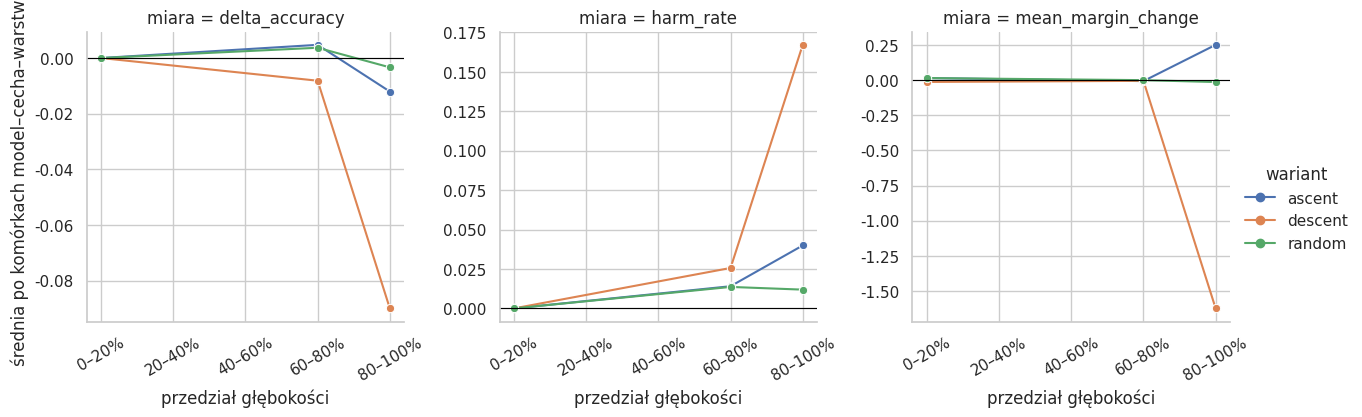

In [4]:
layer_metrics = outcome_metrics(
    accepted, ['model', 'feature_name', 'feature', 'layer_number', 'layer_pct', 'intervention_type']
)
layer_metrics['depth_bin'] = pd.cut(
    layer_metrics['layer_pct'], bins=[0, 20, 40, 60, 80, 100.01],
    labels=['0–20%', '20–40%', '40–60%', '60–80%', '80–100%'],
    include_lowest=True,
)
depth_macro = layer_metrics.groupby(['intervention_type', 'depth_bin'], observed=True).agg(
    delta_accuracy=('delta_accuracy', 'mean'),
    rescue_rate=('rescue_rate', 'mean'),
    harm_rate=('harm_rate', 'mean'),
    mean_margin_change=('mean_margin_change', 'mean'),
).reset_index()
depth_macro['wariant'] = depth_macro['intervention_type'].map(INTERVENTION_LABELS)
display(depth_macro.round(4))

plot_data = depth_macro.melt(
    id_vars=['wariant', 'depth_bin'],
    value_vars=['delta_accuracy', 'harm_rate', 'mean_margin_change'],
    var_name='miara', value_name='wartość',
)
g = sns.relplot(
    data=plot_data, x='depth_bin', y='wartość', hue='wariant',
    col='miara', kind='line', marker='o', height=4, aspect=1.05,
    facet_kws={'sharey': False},
)
g.set_axis_labels('przedział głębokości', 'średnia po komórkach model–cecha–warstwa')
for ax in g.axes.flat:
    ax.axhline(0, color='black', lw=0.8)
    ax.tick_params(axis='x', rotation=30)

## Sparowana przewaga ascent nad kontrolami po warstwach

c:\Users\mikol\OneDrive\Pulpit\Praca Magisterska\Transformer-Decision-Traces\src\analysis\intervention_results.py:160: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = frame.pivot_table(


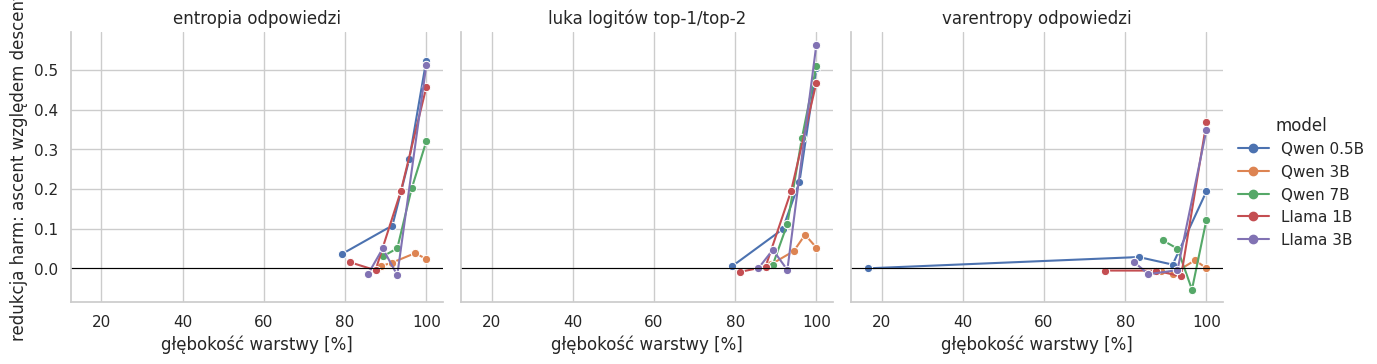

In [5]:
paired_layers = paired_branch_metrics(
    accepted, ['model', 'feature_name', 'feature', 'layer_number', 'layer_pct']
)
g = sns.relplot(
    data=paired_layers, x='layer_pct', y='ascent_vs_descent_harm_reduction',
    hue='model', col='feature', col_wrap=3, kind='line', marker='o',
    height=3.8, aspect=1.1,
)
g.set_axis_labels('głębokość warstwy [%]', 'redukcja harm: ascent względem descent')
g.set_titles('{col_name}')
for ax in g.axes.flat:
    ax.axhline(0, color='black', lw=0.8)

## Efekt według rangi warstwy w rankingu KS

,intervention_type,selection_rank,delta_accuracy,harm_rate,mean_margin_change,mean_ks,wariant
0,ascent,1,-0.0093,0.0334,0.2146,0.3815,ascent
1,ascent,2,-0.0101,0.0430,-0.0703,0.3540,ascent
2,ascent,3,-0.0061,0.0380,0.4186,0.3327,ascent
3,ascent,4,-0.0186,0.0375,0.3698,0.2998,ascent
4,descent,1,-0.1355,0.2243,-2.3471,0.3815,descent
5,descent,2,-0.0508,0.1344,-1.6011,0.3540,descent
6,descent,3,-0.0684,0.1313,-1.0592,0.3327,descent
7,descent,4,-0.0829,0.1390,-1.0538,0.2998,descent
8,random_same_norm,1,-0.0052,0.0150,-0.0156,0.3815,random
9,random_same_norm,2,-0.0037,0.0137,-0.0189,0.3540,random


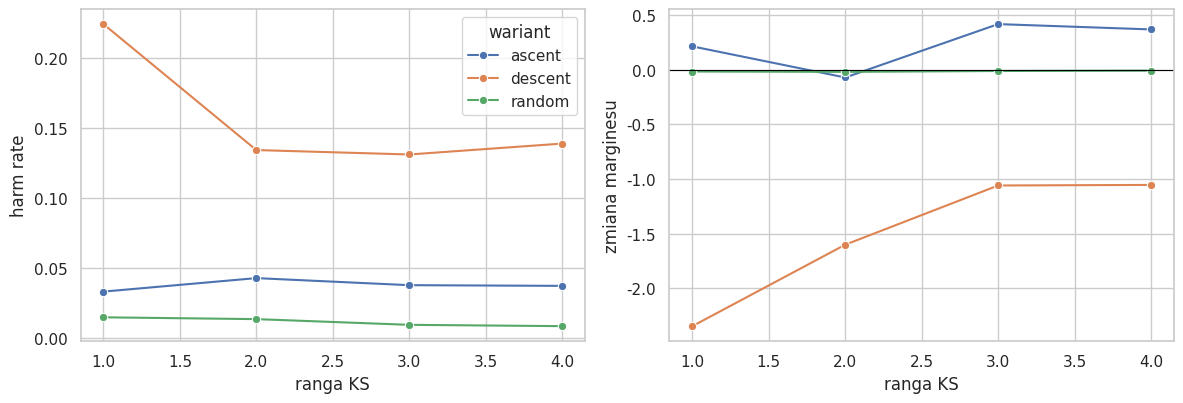

In [6]:
rank_meta = selected[['model', 'feature_name', 'layer_number', 'selection_rank', 'ks_statistic']]
ranked_metrics = layer_metrics.merge(
    rank_meta, on=['model', 'feature_name', 'layer_number'], how='left', validate='many_to_one'
)
rank_macro = ranked_metrics.groupby(['intervention_type', 'selection_rank'], observed=True).agg(
    delta_accuracy=('delta_accuracy', 'mean'),
    harm_rate=('harm_rate', 'mean'),
    mean_margin_change=('mean_margin_change', 'mean'),
    mean_ks=('ks_statistic', 'mean'),
).reset_index()
rank_macro['wariant'] = rank_macro['intervention_type'].map(INTERVENTION_LABELS)
display(rank_macro.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.lineplot(data=rank_macro, x='selection_rank', y='harm_rate', hue='wariant', marker='o', ax=axes[0])
sns.lineplot(data=rank_macro, x='selection_rank', y='mean_margin_change', hue='wariant', marker='o', ax=axes[1])
axes[0].set(xlabel='ranga KS', ylabel='harm rate')
axes[1].set(xlabel='ranga KS', ylabel='zmiana marginesu')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].legend_.remove()
plt.tight_layout()